# Regular Season Placement vs. Stanley Cup Winner

Does finishing higher in the regular season standings make a team more likely to win the Stanley Cup?

This notebook looks at where each Cup winner ranked in the regular season — both league-wide and within their conference — across 7 seasons (2017–18 through 2023–24). A team ranked #1 overall has the best record in the entire league; a conference rank of #1 means best record in their conference.

**Data used:**
- `standings_all.csv` — regular season points and team info per season
- `playoff_matchups.csv` — playoff series results; the Round 4 winner is the Cup champion

## Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

PROCESSED_DIR = Path('..') / 'data' / 'processed'

standings = pd.read_csv(PROCESSED_DIR / 'standings_all.csv', dtype={'season': str})
matchups  = pd.read_csv(PROCESSED_DIR / 'playoff_matchups.csv', dtype={'season': str})

print(f"Standings: {len(standings)} team-seasons across {standings['season'].nunique()} seasons")
print(f"Matchups:  {len(matchups)} playoff series")

Standings: 220 team-seasons across 7 seasons
Matchups:  105 playoff series


## Build standings ranks

For each season, rank every team by points — first league-wide (1 = best record in the NHL), then within their conference (1 = best record in that conference). Ties broken by wins then goal differential.

In [2]:
# League-wide rank: sort within each season, best record = rank 1
standings = standings.sort_values(
    ['season', 'points', 'wins', 'goal_diff'], ascending=[True, False, False, False]
)
standings['league_rank'] = standings.groupby('season').cumcount() + 1

# Conference rank: sort within each season + conference
standings = standings.sort_values(
    ['season', 'conference', 'points', 'wins', 'goal_diff'], ascending=[True, True, False, False, False]
)
standings['conf_rank'] = standings.groupby(['season', 'conference']).cumcount() + 1

standings[['season', 'team', 'conference', 'points', 'league_rank', 'conf_rank']].head(10)

,season,team,conference,points,league_rank,conf_rank
2,20172018,TBL,Eastern,113,3,1.0
3,20172018,BOS,Eastern,112,4,2.0
6,20172018,TOR,Eastern,105,6,3.0
5,20172018,WSH,Eastern,105,7,4.0
9,20172018,PIT,Eastern,100,10,5.0
12,20172018,PHI,Eastern,98,13,6.0
13,20172018,CBJ,Eastern,97,14,7.0
14,20172018,NJD,Eastern,97,15,8.0
15,20172018,FLA,Eastern,96,16,9.0
20,20172018,CAR,Eastern,83,21,10.0


## Identify the Cup winner each season

The Stanley Cup champion is the winner of the Round 4 (Finals) series in each season.

In [3]:
cup_winners = (
    matchups[matchups['round'] == 4][['season', 'winner']]
    .rename(columns={'winner': 'cup_winner'})
    .reset_index(drop=True)
)

# Join with standings to get their regular season rank
cup_data = cup_winners.merge(
    standings[['season', 'team', 'conference', 'points', 'wins', 'goal_diff', 'league_rank', 'conf_rank']],
    left_on=['season', 'cup_winner'],
    right_on=['season', 'team']
).drop(columns='team')

# Tag the #1 overall seed each season for comparison
top_seeds = standings[standings['league_rank'] == 1][['season', 'team']].rename(columns={'team': 'top_seed'})
cup_data = cup_data.merge(top_seeds, on='season')
cup_data['was_top_seed'] = cup_data['cup_winner'] == cup_data['top_seed']

cup_data[['season', 'cup_winner', 'conference', 'points', 'league_rank', 'conf_rank', 'was_top_seed']]

,season,cup_winner,conference,points,league_rank,conf_rank,was_top_seed
0,20172018,WSH,Eastern,105,7,4.0,False
1,20182019,STL,Western,99,12,5.0,False
2,20192020,TBL,Eastern,92,3,2.0,False
3,20202021,TBL,NaN,75,8,NaN,False
4,20212022,COL,Western,119,2,1.0,False
5,20222023,VGK,Western,111,4,1.0,False
6,20232024,FLA,Eastern,110,4,3.0,False


## Cup winner regular season rank by season

Each bar shows where the Cup winner finished in the regular season standings — league rank on the left, conference rank on the right. Lower numbers are better (1 = best record). The y-axis is inverted so rank #1 appears at the top.

The dashed line marks rank 8, which is roughly the playoff cutoff — any team finishing outside the top 8 in their conference doesn't make the playoffs at all. Red bars indicate the Cup winner also finished #1 in the league that season.

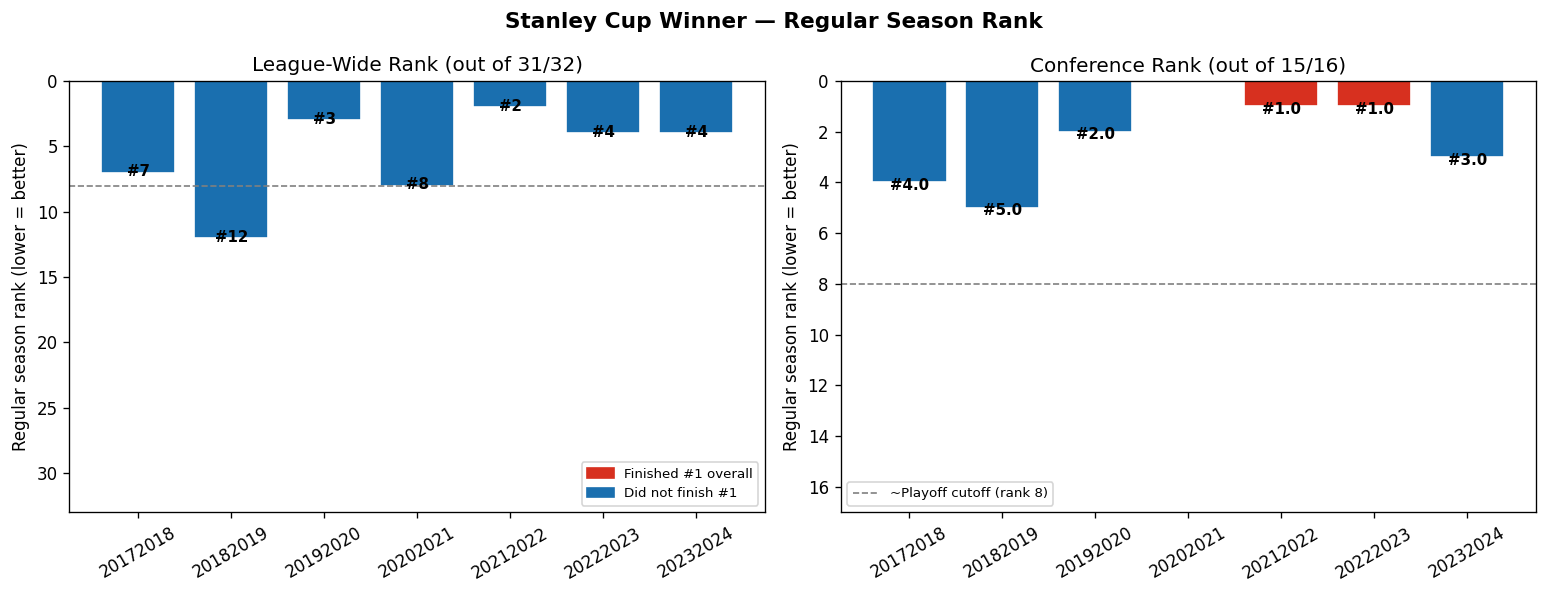

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Stanley Cup Winner — Regular Season Rank', fontsize=13, fontweight='bold')

seasons = cup_data['season'].tolist()
x = range(len(seasons))

for ax, col, title, max_rank in zip(
    axes,
    ['league_rank', 'conf_rank'],
    ['League-Wide Rank (out of 31/32)', 'Conference Rank (out of 15/16)'],
    [32, 16]
):
    colors = ['#d7301f' if r == 1 else '#1a6faf' for r in cup_data[col]]
    bars = ax.bar(x, cup_data[col], color=colors, edgecolor='white')
    ax.axhline(8, color='gray', linestyle='--', linewidth=1, label='~Playoff cutoff (rank 8)')
    ax.set_xticks(list(x))
    ax.set_xticklabels(seasons, rotation=30)
    ax.set_ylabel('Regular season rank (lower = better)')
    ax.set_title(title)
    ax.set_ylim(0, max_rank + 1)
    ax.invert_yaxis()
    ax.legend(fontsize=8)
    for bar, val in zip(bars, cup_data[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'#{val}', ha='center', fontsize=9, fontweight='bold')

red_patch = mpatches.Patch(color='#d7301f', label='Finished #1 overall')
blue_patch = mpatches.Patch(color='#1a6faf', label='Did not finish #1')
axes[0].legend(handles=[red_patch, blue_patch], fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

## Summary stats

Across all 7 seasons, how are Cup winners spread across the standings? This breaks down how often the champion came from the very top of the standings vs. anywhere in the top half of the playoff field.

In [5]:
n = len(cup_data)
print("Cup winners by regular season rank:\n")
for _, row in cup_data.sort_values('season').iterrows():
    marker = '  ← #1 overall' if row['league_rank'] == 1 else ''
    print(f"  {row['season']}  {row['cup_winner']:<5}  "
          f"League #{row['league_rank']:>2}  Conf #{row['conf_rank']}{marker}")

print(f"\nSummary across {n} seasons:")
print(f"  Finished #1 in league:        {(cup_data['league_rank'] == 1).sum()}/{n}")
print(f"  Finished top 4 in league:     {(cup_data['league_rank'] <= 4).sum()}/{n}")
print(f"  Finished top 8 in league:     {(cup_data['league_rank'] <= 8).sum()}/{n}")
print(f"  Finished #1 in conference:    {(cup_data['conf_rank'] == 1).sum()}/{n}")
print(f"  Finished top 4 in conference: {(cup_data['conf_rank'] <= 4).sum()}/{n}")
print(f"\n  Avg league rank of Cup winner: {cup_data['league_rank'].mean():.1f}")
print(f"  Avg conf rank of Cup winner:   {cup_data['conf_rank'].mean():.1f}")

Cup winners by regular season rank:

  20172018  WSH    League # 7  Conf #4.0
  20182019  STL    League #12  Conf #5.0
  20192020  TBL    League # 3  Conf #2.0
  20202021  TBL    League # 8  Conf #nan
  20212022  COL    League # 2  Conf #1.0
  20222023  VGK    League # 4  Conf #1.0
  20232024  FLA    League # 4  Conf #3.0

Summary across 7 seasons:
  Finished #1 in league:        0/7
  Finished top 4 in league:     4/7
  Finished top 8 in league:     6/7
  Finished #1 in conference:    2/7
  Finished top 4 in conference: 5/7

  Avg league rank of Cup winner: 5.7
  Avg conf rank of Cup winner:   2.7


## Cup winner vs. the rest of the playoff field

For each season, every playoff team's regular season point total is shown, with the Cup winner highlighted in red. This gives a sense of whether the champion was clearly the best team going into the playoffs, or whether a lower-ranked team ran the table.

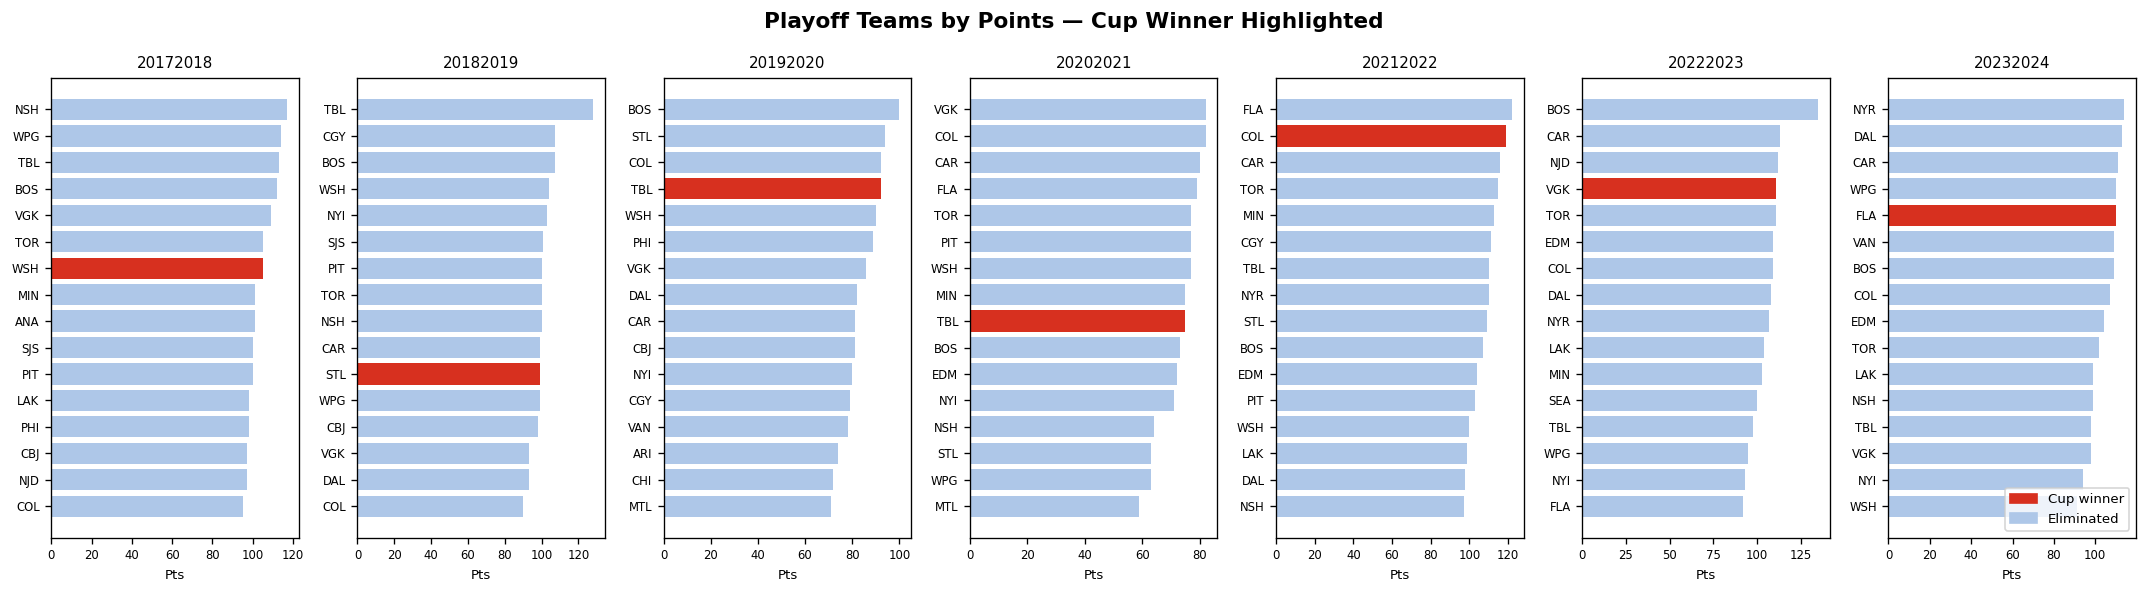

In [6]:
# Identify playoff teams each season
playoff_teams = pd.concat([
    matchups[['season', 'team_hi']].rename(columns={'team_hi': 'team'}),
    matchups[['season', 'team_lo']].rename(columns={'team_lo': 'team'})
]).drop_duplicates()

playoff_standings = playoff_teams.merge(standings, on=['season', 'team'])

seasons_sorted = sorted(cup_data['season'].unique())
fig, axes = plt.subplots(1, len(seasons_sorted), figsize=(18, 5))
fig.suptitle('Playoff Teams by Points — Cup Winner Highlighted', fontsize=13, fontweight='bold')

for ax, season in zip(axes, seasons_sorted):
    season_teams = playoff_standings[playoff_standings['season'] == season].sort_values('points')
    cup_team = cup_data[cup_data['season'] == season]['cup_winner'].values[0]
    colors = ['#d7301f' if t == cup_team else '#aec7e8' for t in season_teams['team']]
    ax.barh(season_teams['team'], season_teams['points'], color=colors)
    ax.set_title(season, fontsize=9)
    ax.set_xlabel('Pts', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.tick_params(axis='x', labelsize=7)

red_patch = mpatches.Patch(color='#d7301f', label='Cup winner')
blue_patch = mpatches.Patch(color='#aec7e8', label='Eliminated')
axes[-1].legend(handles=[red_patch, blue_patch], fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

## Regular season points vs. playoff rounds won

A team's deepest playoff run is measured by how many rounds they won (0–4, where 4 = Stanley Cup champion). This scatter shows all 16 playoff teams across all 7 seasons.

If regular season record were a strong predictor of playoff success, we'd see a clear upward trend — more points leading to more rounds won. The trend line and correlation coefficient tell us how much signal actually exists. Cup winners are labelled in red.

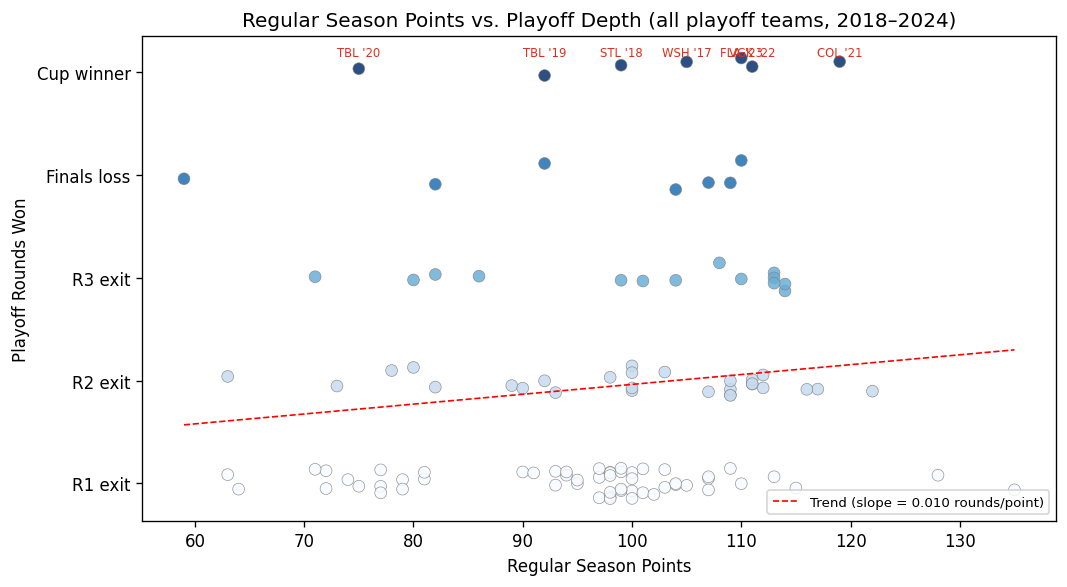

Pearson r between regular-season points and rounds won: 0.118


In [7]:
# Count rounds won per team per season
rounds_won = (
    matchups.groupby(['season', 'winner'])
    .size()
    .reset_index(name='rounds_won')
    .rename(columns={'winner': 'team'})
)

all_playoff = playoff_teams.copy()
all_playoff = all_playoff.merge(rounds_won, on=['season', 'team'], how='left')
all_playoff['rounds_won'] = all_playoff['rounds_won'].fillna(0).astype(int)
all_playoff = all_playoff.merge(
    standings[['season', 'team', 'points', 'league_rank']], on=['season', 'team']
)

fig, ax = plt.subplots(figsize=(9, 5))
jitter = np.random.uniform(-0.15, 0.15, len(all_playoff))
ax.scatter(
    all_playoff['points'],
    all_playoff['rounds_won'] + jitter,
    c=all_playoff['rounds_won'], cmap='Blues',
    edgecolors='gray', linewidths=0.4, s=50, alpha=0.85
)

# Label Cup winners
for _, row in cup_data.iterrows():
    team_row = all_playoff[(all_playoff['season'] == row['season']) &
                           (all_playoff['team'] == row['cup_winner'])]
    if not team_row.empty:
        ax.annotate(
            f"{row['cup_winner']} '{row['season'][2:4]}",
            xy=(team_row['points'].values[0], 4),
            fontsize=7, color='#d7301f', ha='center',
            xytext=(0, 10), textcoords='offset points'
        )

# Trend line
z = np.polyfit(all_playoff['points'], all_playoff['rounds_won'], 1)
xs = np.linspace(all_playoff['points'].min(), all_playoff['points'].max(), 100)
ax.plot(xs, np.poly1d(z)(xs), color='red', linestyle='--', linewidth=1,
        label=f'Trend (slope = {z[0]:.3f} rounds/point)')

ax.set_xlabel('Regular Season Points')
ax.set_ylabel('Playoff Rounds Won')
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_yticklabels(['R1 exit', 'R2 exit', 'R3 exit', 'Finals loss', 'Cup winner'])
ax.set_title('Regular Season Points vs. Playoff Depth (all playoff teams, 2018–2024)')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

corr = all_playoff[['points', 'rounds_won']].corr().iloc[0, 1]
print(f"Pearson r between regular-season points and rounds won: {corr:.3f}")